# Pre-processamento

In [ ]:
import re
from pathlib import Path

def preprocess_line(line):
    line = line.lower()
    line = re.sub(r'[^a-zà-ú\s]', ' ', line)
    line = re.sub(r'\s+', ' ', line).strip()
    tokens = line.split()
    return tokens

book_names = [
    'Harry Potter e A Pedra Filosofal.txt',
    'Harry_Potter_Camara_Secreta-br.txt',
    'Livro Harry Potter e o Prisioneiro de Azkaban.txt',
    'Livro Harry Potter e o Cálice de Fogo.txt',
    'Livro Harry Potter e a Ordem da Fênix.txt',
    'Livro Harry Potter e o enigma do Príncipe.txt',
    'Livro Harry Potter e as Relíquias da Morte.txt'
 ]

# Pasta de dados fixa (como pedido): TXT
data_dir = Path('TXT')
missing_files = [name for name in book_names if not (data_dir / name).exists()]
if missing_files:
    raise FileNotFoundError(f'Ficheiros em falta na pasta TXT: {missing_files}')

book_files = [str(data_dir / name) for name in book_names]

sentences = []

for file_name in book_files:
    with open(file_name, encoding='utf-8') as f:
        for line in f:
            tokens = preprocess_line(line)
            if tokens:
                sentences.append(tokens)

print(len(sentences))
print(sentences)

Diretorio de dados: TXT
118958
[['dados', 'de', 'copyright'], ['sobre', 'a', 'obra'], ['a', 'presente', 'obra', 'é', 'disponibilizada', 'pela', 'equipe', 'le', 'livros', 'e', 'seus', 'diversos', 'parceiros', 'com', 'o'], ['objetivo', 'de', 'oferecer', 'conteúdo', 'para', 'uso', 'parcial', 'em', 'pesquisas', 'e', 'estudos', 'acadêmicos', 'bem', 'como'], ['o', 'simples', 'teste', 'da', 'qualidade', 'da', 'obra', 'com', 'o', 'fim', 'exclusivo', 'de', 'compra', 'futura'], ['é', 'expressamente', 'proibida', 'e', 'totalmente', 'repudíavel', 'a', 'venda', 'aluguel', 'ou', 'quaisquer', 'uso'], ['comercial', 'do', 'presente', 'conteúdo'], ['sobre', 'nós'], ['o', 'le', 'livros', 'e', 'seus', 'parceiros', 'disponibilizam', 'conteúdo', 'de', 'dominio', 'publico', 'e', 'propriedade'], ['intelectual', 'de', 'forma', 'totalmente', 'gratuita', 'por', 'acreditar', 'que', 'o', 'conhecimento', 'e', 'a', 'educação', 'devem'], ['ser', 'acessíveis', 'e', 'livres', 'a', 'toda', 'e', 'qualquer', 'pessoa', 'vo

# Modelo

In [40]:
from gensim.models import Word2Vec
model_hp = Word2Vec(sentences = sentences, vector_size=300, epochs=20)

In [24]:
model_hp.wv["harry"]

array([ 0.94761145, -0.27827755, -0.5024974 ,  0.19820812, -0.1433893 ,
       -0.5602061 ,  0.772001  ,  1.0524508 , -0.8953415 , -0.2441943 ,
       -0.187387  ,  0.08181009, -0.27123505,  0.04094227,  0.38661224,
        0.3212495 , -0.11643239,  1.4654605 ,  1.0345614 ,  1.3494219 ,
        0.7348948 ,  0.08450374,  0.01152219,  0.09981965,  1.0708853 ,
       -0.8972305 ,  0.27724054, -0.02996161,  0.65475553, -0.57466036,
        0.0289443 ,  0.17550468, -0.5254588 , -0.8365461 , -0.11852944,
        0.14158422, -0.39531094, -0.01890263,  0.6061286 , -0.31727484,
        0.5323173 , -0.5857135 ,  0.43801835,  0.28425556, -0.84831583,
        0.46885827, -0.5195585 , -0.17389983,  0.53200704, -0.10275267,
       -0.24594106, -0.3429346 ,  0.46784458, -0.00661006, -0.6530563 ,
        0.40808094,  0.45321858,  0.6166163 ,  0.926376  ,  0.03706551,
       -1.1614376 ,  1.1256167 ,  1.5422568 ,  0.16337113,  0.17407094,
        0.27485767,  0.18172072,  0.22844078, -0.5146858 ,  0.28

In [25]:
model_hp.wv.most_similar('harry')

[('garoto', 0.5218225121498108),
 ('cho', 0.4827251136302948),
 ('arry', 0.46491745114326477),
 ('ele', 0.46106985211372375),
 ('lalau', 0.41064944863319397),
 ('moody', 0.40588584542274475),
 ('franco', 0.3977954387664795),
 ('gina', 0.3882048726081848),
 ('karkaroff', 0.3845060467720032),
 ('mione', 0.37954181432724)]

In [26]:
# Vetor para representar a frase toda
frase = (model_hp.wv["o"] + model_hp.wv["harry"] + model_hp.wv["é"] + model_hp.wv["amigo"] + model_hp.wv["do"] + model_hp.wv["rony"]) / 6

In [27]:
result = model_hp.wv.most_similar(positive=['harry', 'mulher'], negative=['homem'])
print(result)

[('amiga', 0.5043374300003052), ('garota', 0.49911829829216003), ('gina', 0.43872296810150146), ('menina', 0.43313318490982056), ('mione', 0.4229884147644043), ('coruja', 0.413736492395401), ('turma', 0.4102398455142975), ('nimbus', 0.40866443514823914), ('aluna', 0.4045920670032501), ('padma', 0.3980674743652344)]


In [28]:
model_hp.wv.doesnt_match(['harry', 'hermione', 'rony', 'dumbledore'])

'dumbledore'

In [62]:
model_hp.wv.save_word2vec_format('model_harry.txt', binary=False)
#projector.tensorflow.org

In [63]:
!python -m gensim.scripts.word2vec2tensor -i model_harry.txt -o model_harry

2026-04-13 23:08:16,266 - word2vec2tensor - INFO - running c:\Users\Utilizador\AppData\Local\Programs\Python\Python312\Lib\site-packages\gensim\scripts\word2vec2tensor.py -i model_harry.txt -o model_harry
2026-04-13 23:08:16,266 - keyedvectors - INFO - loading projection weights from model_harry.txt
2026-04-13 23:08:34,281 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (11329, 300) matrix of type float32 from model_harry.txt', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-04-13T23:08:33.578352', 'gensim': '4.4.0', 'python': '3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'load_word2vec_format'}
2026-04-13 23:08:39,711 - word2vec2tensor - INFO - 2D tensor file saved to model_harry_tensor.tsv
2026-04-13 23:08:39,711 - word2vec2tensor - INFO - Tensor metadata file saved to model_harry_metadata.tsv
2026-04-13 23:08:39,714 - word2vec2tensor - INFO - finished running word2vec2tensor.

## Testes de Similaridade 
Abaixo estão exemplos adicionais para explorar o modelo treinado com os livros de Harry Potter.

In [49]:
wv = model_hp.wv
vocab = set(wv.index_to_key)

def canonical_token(word):
    if 'name_aliases' in globals():
        return name_aliases.get(word, word)
    return word

def canonicalize_words(words):
    return [canonical_token(w) for w in words]

def has_words(words):
    canon = canonicalize_words(words)
    missing = [w for w in canon if w not in vocab]
    return missing

In [50]:
queries = ['harry', 'rony', 'hermione', 'hogwarts', 'dumbledore']

for q in queries:
    qc = canonical_token(q)
    if qc in vocab:
        print(f"\nmost_similar('{q}' -> '{qc}')")
        print(wv.most_similar(qc, topn=8))
    else:
        print(f"'{q}' (canon: '{qc}') nao existe no vocabulario")


most_similar('harry' -> 'harry_potter')
[('garoto', 0.5210142731666565), ('ele', 0.5134435296058655), ('cho', 0.48407724499702454), ('moody', 0.4165530800819397), ('neville_longbottom', 0.40160077810287476), ('franco', 0.3984110355377197), ('karkaroff', 0.3932269513607025), ('lalau', 0.3925096392631531)]

most_similar('rony' -> 'rony_weasley')
[('gina', 0.5477633476257324), ('cho', 0.524824321269989), ('neville_longbottom', 0.47885581851005554), ('olivio_wood', 0.46997809410095215), ('travers', 0.46089595556259155), ('simas', 0.4556666314601898), ('lalau', 0.4393317997455597), ('luna', 0.435438334941864)]

most_similar('hermione' -> 'hermione_granger')
[('grampo', 0.4690881669521332), ('cho', 0.46064522862434387), ('garota', 0.4541351795196533), ('luna', 0.43697983026504517), ('zangado', 0.421651691198349), ('parvati', 0.4142182469367981), ('lilá', 0.41325485706329346), ('pettigrew', 0.4026596248149872)]

most_similar('hogwarts' -> 'hogwarts')
[('azkaban', 0.6288490295410156), ('hogsm

In [51]:
pairs = [
    ('harry', 'rony'),
    ('harry', 'hermione'),
    ('harry', 'voldemort'),
    ('hogwarts', 'escola')
]

for w1, w2 in pairs:
    c1, c2 = canonicalize_words([w1, w2])
    missing = has_words([w1, w2])
    if not missing:
        print(f"similarity('{w1}', '{w2}') [{c1}, {c2}] = {wv.similarity(c1, c2):.4f}")
    else:
        print(f"Par ignorado (fora do vocabulario): {missing}")

similarity('harry', 'rony') [harry_potter, rony_weasley] = 0.3533
similarity('harry', 'hermione') [harry_potter, hermione_granger] = 0.2856
similarity('harry', 'voldemort') [harry_potter, voldemort] = 0.2070
similarity('hogwarts', 'escola') [hogwarts, escola] = 0.4783


In [52]:
groups = [
    ['harry', 'rony', 'hermione', 'vassoura'],
    ['hogwarts', 'dumbledore', 'snape', 'escola']
]

for g in groups:
    gc = canonicalize_words(g)
    missing = has_words(g)
    if not missing:
        print(f"Grupo: {g} -> {gc}")
        print('doesnt_match ->', wv.doesnt_match(gc))
    else:
        print(f"Grupo ignorado (fora do vocabulario): {missing}")

Grupo: ['harry', 'rony', 'hermione', 'vassoura'] -> ['harry_potter', 'rony_weasley', 'hermione_granger', 'vassoura']
doesnt_match -> vassoura
Grupo: ['hogwarts', 'dumbledore', 'snape', 'escola'] -> ['hogwarts', 'alvo_dumbledore', 'severo_snape', 'escola']
doesnt_match -> severo_snape


In [53]:
def analogy(x2, y1, x1, topn=5):
    cx2, cy1, cx1 = canonicalize_words([x2, y1, x1])
    missing = [w for w in [cx2, cy1, cx1] if w not in vocab]
    if missing:
        return f"Nao foi possivel calcular; faltam: {missing}"
    return wv.most_similar(positive=[cy1, cx2], negative=[cx1], topn=topn)

print("harry : rony :: hermione : ?")
print(analogy('rony', 'hermione', 'harry'))

print("dumbledore : hogwarts :: hagrid : ?")
print(analogy('hogwarts', 'hagrid', 'dumbledore'))

harry : rony :: hermione : ?
[('luna', 0.4127022922039032), ('parvati', 0.38948580622673035), ('lilá', 0.37702324986457825), ('gina', 0.3649846017360687), ('grampo', 0.36175838112831116)]
dumbledore : hogwarts :: hagrid : ?
[('hogsmeade', 0.4062312841415405), ('londres', 0.40328171849250793), ('gruta', 0.3336845636367798), ('caça', 0.3187982738018036), ('azkaban', 0.3143962323665619)]


## Visualizacao (PCA Scatterplot)

Representacao 2D de alguns termos para observar agrupamentos semanticos.

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def display_pca_scatterplot(model, words):
    valid_words = [w for w in words if w in model]
    if len(valid_words) < 3:
        print('Poucas palavras no vocabulario para gerar grafico.')
        print('Disponiveis:', valid_words)
        return

    word_vectors = np.array([model[w] for w in valid_words])
    twodim = PCA(n_components=2).fit_transform(word_vectors)

    plt.figure(figsize=(10, 7))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='royalblue')
    for word, (x, y) in zip(valid_words, twodim):
        plt.text(x + 0.02, y + 0.02, word, fontsize=10)

    plt.title('PCA de palavras do universo Harry Potter')
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.grid(alpha=0.2)
    plt.show()

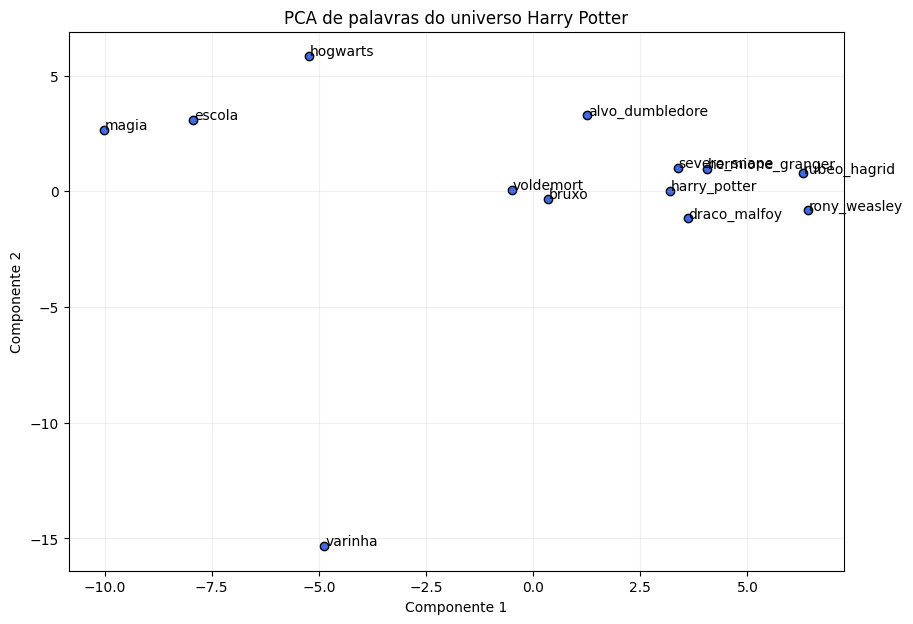

In [55]:
words_hp = [
    'harry', 'rony', 'hermione', 'dumbledore', 'snape',
    'hogwarts', 'hagrid', 'voldemort', 'draco', 'varinha',
    'feitico', 'escola', 'magia', 'bruxo'
]

words_hp_canon = []
for w in words_hp:
    wc = canonical_token(w)
    if wc not in words_hp_canon:
        words_hp_canon.append(wc)

display_pca_scatterplot(wv, words_hp_canon)

## Testes adicionais

Mais exemplos de most_similar, similarity, doesnt_match e analogy para consolidar as observacoes do modelo.

In [56]:
extra_queries = ['rony', 'snape', 'voldemort', 'hagrid']

print('=== most_similar (extra) ===')
for q in extra_queries:
    qc = canonical_token(q)
    if qc in vocab:
        top = wv.most_similar(qc, topn=5)
        print(f"{q} -> {qc}: {top}")
    else:
        print(f"{q}: fora do vocabulario (canon: {qc})")

print('\n=== similarity (extra) ===')
extra_pairs = [
    ('harry', 'rony'),
    ('harry', 'snape'),
    ('hermione', 'rony'),
    ('voldemort', 'dumbledore'),
    ('hagrid', 'dumbledore')
]
for w1, w2 in extra_pairs:
    c1, c2 = canonicalize_words([w1, w2])
    if not has_words([w1, w2]):
        print(f"sim({w1}, {w2}) [{c1}, {c2}] = {wv.similarity(c1, c2):.4f}")
    else:
        print(f"sim({w1}, {w2}) = indisponivel")

=== most_similar (extra) ===
rony -> rony_weasley: [('gina', 0.5477633476257324), ('cho', 0.524824321269989), ('neville_longbottom', 0.47885581851005554), ('olivio_wood', 0.46997809410095215), ('travers', 0.46089595556259155)]
snape -> severo_snape: [('moody', 0.5955274105072021), ('quirrell', 0.5738347172737122), ('slughorn', 0.5728428959846497), ('lockhart', 0.5562702417373657), ('binns', 0.5361229181289673)]
voldemort -> voldemort: [('cedrico', 0.5238792896270752), ('rabicho', 0.512197732925415), ('trevas', 0.5090120434761047), ('lorde', 0.4818606376647949), ('alvo_dumbledore', 0.475848913192749)]
hagrid -> rubeo_hagrid: [('moody', 0.45855849981307983), ('lalau', 0.429487943649292), ('grampo', 0.4284301698207855), ('slughorn', 0.4262773394584656), ('rony_weasley', 0.4228678345680237)]

=== similarity (extra) ===
sim(harry, rony) [harry_potter, rony_weasley] = 0.3533
sim(harry, snape) [harry_potter, severo_snape] = 0.2698
sim(hermione, rony) [hermione_granger, rony_weasley] = 0.2569


In [57]:
print('=== doesnt_match (extra) ===')
extra_groups = [
    ['harry', 'rony', 'hermione', 'voldemort'],
    ['snape', 'dumbledore', 'hagrid', 'varinha'],
    ['hogwarts', 'magia', 'escola', 'draco']
]
for group in extra_groups:
    group_c = canonicalize_words(group)
    missing = has_words(group)
    if not missing:
        print(group, '->', group_c, '->', wv.doesnt_match(group_c))
    else:
        print(group, '-> faltam:', missing)

print('\n=== analogy (extra) ===')
print("harry : hermione :: rony : ?")
print(analogy('hermione', 'rony', 'harry', topn=3))

print("snape : dumbledore :: draco : ?")
print(analogy('dumbledore', 'draco', 'snape', topn=3))

=== doesnt_match (extra) ===
['harry', 'rony', 'hermione', 'voldemort'] -> ['harry_potter', 'rony_weasley', 'hermione_granger', 'voldemort'] -> voldemort
['snape', 'dumbledore', 'hagrid', 'varinha'] -> ['severo_snape', 'alvo_dumbledore', 'rubeo_hagrid', 'varinha'] -> varinha
['hogwarts', 'magia', 'escola', 'draco'] -> ['hogwarts', 'magia', 'escola', 'draco_malfoy'] -> draco_malfoy

=== analogy (extra) ===
harry : hermione :: rony : ?
[('luna', 0.4127022922039032), ('parvati', 0.38948580622673035), ('lilá', 0.37702324986457825)]
snape : dumbledore :: draco : ?
[('crouch', 0.37747722864151), ('borgin', 0.34676724672317505), ('gaunt', 0.3442423939704895)]


In [58]:
print('=== Resumo corpus/modelo ===')
print('num_sentencas =', len(sentences))
print('vocab_size =', len(wv.index_to_key))

print('\n=== most_similar (base resumido) ===')
for q in ['harry', 'rony', 'hermione', 'hogwarts', 'dumbledore']:
    qc = canonical_token(q)
    if qc in wv.key_to_index:
        print(f"{q} -> {qc}: {wv.most_similar(qc, topn=5)}")
    else:
        print(f"{q} -> {qc}: fora do vocabulario")

=== Resumo corpus/modelo ===
num_sentencas = 118958
vocab_size = 11329

=== most_similar (base resumido) ===
harry -> harry_potter: [('garoto', 0.5210142731666565), ('ele', 0.5134435296058655), ('cho', 0.48407724499702454), ('moody', 0.4165530800819397), ('neville_longbottom', 0.40160077810287476)]
rony -> rony_weasley: [('gina', 0.5477633476257324), ('cho', 0.524824321269989), ('neville_longbottom', 0.47885581851005554), ('olivio_wood', 0.46997809410095215), ('travers', 0.46089595556259155)]
hermione -> hermione_granger: [('grampo', 0.4690881669521332), ('cho', 0.46064522862434387), ('garota', 0.4541351795196533), ('luna', 0.43697983026504517), ('zangado', 0.421651691198349)]
hogwarts -> hogwarts: [('azkaban', 0.6288490295410156), ('hogsmeade', 0.6246992349624634), ('setembro', 0.5579131841659546), ('durmstrang', 0.5391502380371094), ('segurança', 0.5008504986763)]
dumbledore -> alvo_dumbledore: [('diretor', 0.5426121950149536), ('binns', 0.508546769618988), ('slughorn', 0.50744611024

## Fase 3 - Normalizacao de nomes (aliases)

Nesta fase, aplicamos uma lista de nomes/variantes para consolidar tokens que representam a mesma personagem.
Exemplo: `mione` -> `hermione`, para evitar duplicacao semantica no vocabulario.

In [41]:
# Fase 3: normalizacao de nomes com mapa de aliases (1, 2 e 3 palavras)
MAPA_NOMES = {
    'sr. potter': 'Harry Potter',
    'harry': 'Harry Potter',
    'harry potter': 'Harry Potter',
    'potter': 'Harry Potter',

    'rony': 'Rony Weasley',
    'rony weasley': 'Rony Weasley',
    'ron': 'Rony Weasley',

    'hermione': 'Hermione Granger',
    'hermione granger': 'Hermione Granger',
    'mione': 'Hermione Granger',

    'hagrid': 'Rubeo Hagrid',
    'rubeo hagrid': 'Rubeo Hagrid',
    'rubéo hagrid': 'Rubeo Hagrid',

    'dumbledore': 'Alvo Dumbledore',
    'alvo dumbledore': 'Alvo Dumbledore',
    'professor dumbledore': 'Alvo Dumbledore',

    'snape': 'Severo Snape',
    'severo snape': 'Severo Snape',
    'professor snape': 'Severo Snape',

    'mcgonagall': 'Minerva McGonagall',
    'minerva': 'Minerva McGonagall',
    'minerva mcgonagall': 'Minerva McGonagall',
    'professora mcgonagall': 'Minerva McGonagall',

    'draco': 'Draco Malfoy',
    'malfoy': 'Draco Malfoy',
    'draco malfoy': 'Draco Malfoy',

    'neville': 'Neville Longbottom',
    'neville longbottom': 'Neville Longbottom',

    'fred': 'Fred Weasley',
    'fred weasley': 'Fred Weasley',

    'jorge': 'Jorge Weasley',
    'george': 'Jorge Weasley',
    'jorge weasley': 'Jorge Weasley',

    'percy': 'Percy Weasley',
    'percy weasley': 'Percy Weasley',

    'duda': 'Dudley Dursley',
    'dudley': 'Dudley Dursley',

    'valter': 'Vernon Dursley',
    'vernon': 'Vernon Dursley',
    'tio valter': 'Vernon Dursley',
    'válter': 'Vernon Dursley',
    'tio válter': 'Vernon Dursley',

    'petunia': 'Petunia Dursley',
    'tia petunia': 'Petunia Dursley',
    'petúnia': 'Petunia Dursley',
    'tia petúnia': 'Petunia Dursley',

    'olivio': 'Olivio Wood',
    'olivio wood': 'Olivio Wood',
    'olívio': 'Olivio Wood',
    'olívio wood': 'Olivio Wood',
    'wood': 'Olivio Wood',

    'flamel': 'Nicolau Flamel',
    'nicolau flamel': 'Nicolau Flamel',

    'quirrell': 'Quirrell',
    'voldemort': 'Voldemort',
    'crabbe': 'Crabbe',
    'goyle': 'Goyle',
    'filch': 'Argus Filch',

    'seamus': 'Seamus Finnigan',
    'seamus finnigan': 'Seamus Finnigan',

    'lavender': 'Lavender Brown',
    'lavender brown': 'Lavender Brown',

    'lee': 'Lee Jordan',
    'lee jordan': 'Lee Jordan',

    'argus': 'Argus Filch',
    'argus filch': 'Argus Filch',

    'lupin': 'Lupin',
    'arry': 'Harry Potter'
}

def normalize_text_for_map(text):
    text = text.lower()
    text = re.sub(r'[^a-zà-ú\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# chaves no mesmo formato do preprocessamento e valores canonicos como token unico
name_aliases = {
    normalize_text_for_map(k): normalize_text_for_map(v).replace(' ', '_')
    for k, v in MAPA_NOMES.items()
}

def normalize_tokens_with_name_map(tokens, alias_map, max_n=3):
    normalized = []
    i = 0
    n_tokens = len(tokens)
    while i < n_tokens:
        matched = False
        for n in range(min(max_n, n_tokens - i), 0, -1):
            candidate = ' '.join(tokens[i:i+n])
            if candidate in alias_map:
                normalized.append(alias_map[candidate])
                i += n
                matched = True
                break
        if not matched:
            normalized.append(tokens[i])
            i += 1
    return normalized

sentences_f3 = []
for file_name in book_files:
    with open(file_name, encoding='utf-8') as f:
        for line in f:
            tokens = preprocess_line(line)
            if tokens:
                sentences_f3.append(normalize_tokens_with_name_map(tokens, name_aliases, max_n=3))

model_hp_f3 = Word2Vec(sentences=sentences_f3, vector_size=300, epochs=20)
wv_f3 = model_hp_f3.wv

print('num_sentencas_f3 =', len(sentences_f3))
print('vocab_size_f3 =', len(wv_f3.index_to_key))

num_sentencas_f3 = 118958
vocab_size_f3 = 11329


In [42]:
print('=== Validacao Fase 3 ===')
checks = [
    'mione',
    'hermione',
    'hermione_granger',
    'harry',
    'arry',
    'harry_potter',
    'ron',
    'rony',
    'rony_weasley',
    'snape',
    'severo_snape',
    'dumbledore',
    'alvo_dumbledore',
    'malfoy',
    'draco_malfoy'
 ]
for token in checks:
    print(f"{token}:", token in wv_f3.key_to_index)

print("\nmost_similar('hermione_granger') (Fase 3)")
print(wv_f3.most_similar('hermione_granger', topn=10))

print("\nmost_similar('harry_potter') (Fase 3)")
print(wv_f3.most_similar('harry_potter', topn=10))

print("\nsimilarity('harry_potter', 'rony_weasley') (Fase 3) =", round(wv_f3.similarity('harry_potter', 'rony_weasley'), 4))

=== Validacao Fase 3 ===
mione: False
hermione: False
hermione_granger: True
harry: False
arry: False
harry_potter: True
ron: False
rony: False
rony_weasley: True
snape: False
severo_snape: True
dumbledore: False
alvo_dumbledore: True
malfoy: False
draco_malfoy: True

most_similar('hermione_granger') (Fase 3)
[('grampo', 0.4690881669521332), ('cho', 0.46064522862434387), ('garota', 0.4541351795196533), ('luna', 0.43697983026504517), ('zangado', 0.421651691198349), ('parvati', 0.4142182469367981), ('lilá', 0.41325485706329346), ('pettigrew', 0.4026596248149872), ('nervoso', 0.4025685489177704), ('entusiasmado', 0.39638006687164307)]

most_similar('harry_potter') (Fase 3)
[('garoto', 0.5210142731666565), ('ele', 0.5134435296058655), ('cho', 0.48407724499702454), ('moody', 0.4165530800819397), ('neville_longbottom', 0.40160077810287476), ('franco', 0.3984110355377197), ('karkaroff', 0.3932269513607025), ('lalau', 0.3925096392631531), ('gina', 0.3908284902572632), ('slughorn', 0.3888036906

In [43]:
# Ativar Fase 3 como modelo principal para os testes seguintes
model_hp = model_hp_f3
wv = wv_f3
vocab = set(wv.index_to_key)
print('Modelo ativo para testes: Fase 3')
print('vocab_size_ativo =', len(vocab))

Modelo ativo para testes: Fase 3
vocab_size_ativo = 11329
